In [ ]:
"""
BUSINESS PROBLEM

An e-commerce company is facing challenges in retaining customers after their first purchase,
leading to reduced repeat purchases and potential revenue loss over time.

While new customers are being acquired successfully, it is unclear how many of them
continue to engage with the platform in subsequent months.

OBJECTIVE

Analyze customer retention behavior using cohort analysis to:

- Measure how many customers return after their first purchase
- Track retention trends over time
- Identify drop-off patterns across customer cohorts
- Provide insights to improve customer retention and lifetime value
"""

In [2]:
import pandas as pd

# Load datasets
orders = pd.read_csv("D:/DataAnalytics/olist/olist_orders_dataset.csv")
customers = pd.read_csv("D:/DataAnalytics/olist/olist_customers_dataset.csv")

orders.columns


# Merge datasets
#df = orders.merge(customers, on='customer_id', how='left')

#df.head()

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [3]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [5]:
df = orders.merge(customers, on='customer_id',how='left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [6]:
df = df[['customer_unique_id', 'order_id', 'order_purchase_timestamp']]

df.head()

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39


In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        99441 non-null  object        
 1   order_id                  99441 non-null  object        
 2   order_purchase_timestamp  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 2.3+ MB


In [9]:
df['cohort_month'] = df.groupby('customer_unique_id')['order_purchase_timestamp'] \
                        .transform('min') \
                        .dt.to_period('M')
df['cohort_month']

0        2017-09
1        2018-07
2        2018-08
3        2017-11
4        2018-02
          ...   
99436    2017-03
99437    2018-02
99438    2017-08
99439    2018-01
99440    2018-03
Name: cohort_month, Length: 99441, dtype: period[M]

In [10]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['order_month']

0        2017-10
1        2018-07
2        2018-08
3        2017-11
4        2018-02
          ...   
99436    2017-03
99437    2018-02
99438    2017-08
99439    2018-01
99440    2018-03
Name: order_month, Length: 99441, dtype: period[M]

In [11]:
df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12 +
    (df['order_month'].dt.month - df['cohort_month'].dt.month)
)
df['cohort_index']

0        1
1        0
2        0
3        0
4        0
        ..
99436    0
99437    0
99438    0
99439    0
99440    0
Name: cohort_index, Length: 99441, dtype: int64

In [12]:
df[['customer_unique_id','cohort_month','order_month','cohort_index']].head(10)

,customer_unique_id,cohort_month,order_month,cohort_index
0,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10,1
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,0
5,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07,0
6,36edbb3fb164b1f16485364b6fb04c73,2017-04,2017-04,0
7,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05,0
8,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01,0
9,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07,0


In [13]:
df['cohort_index'].min(), df['cohort_index'].max()

(0, 20)

In [16]:
cohort_data = df.groupby(['cohort_month', 'cohort_index']) \
                ['customer_unique_id'].nunique() \
                .reset_index()
cohort_data

,cohort_month,cohort_index,customer_unique_id
0,2016-09,0,4
1,2016-10,0,321
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
...,...,...,...
220,2018-08,0,6271
221,2018-08,1,7
222,2018-08,2,2
223,2018-09,0,5


In [18]:
cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)
cohort_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2636.0,13.0,10.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,4.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2352.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,5.0,NaN,NaN,NaN
2017-05,3596.0,18.0,18.0,14.0,11.0,12.0,15.0,6.0,9.0,11.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3139.0,15.0,11.0,13.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


In [21]:
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

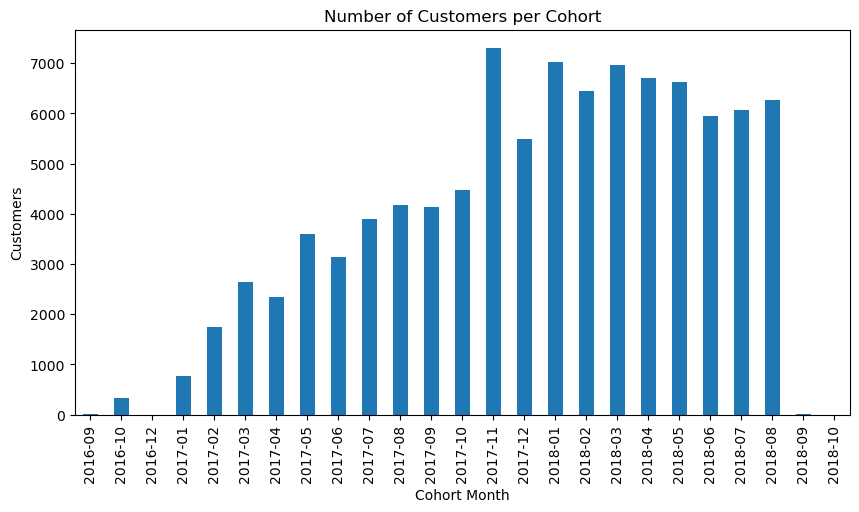

In [24]:
cohort_size.plot(kind='bar', figsize=(10,5))
plt.title("Number of Customers per Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Customers")
plt.show()

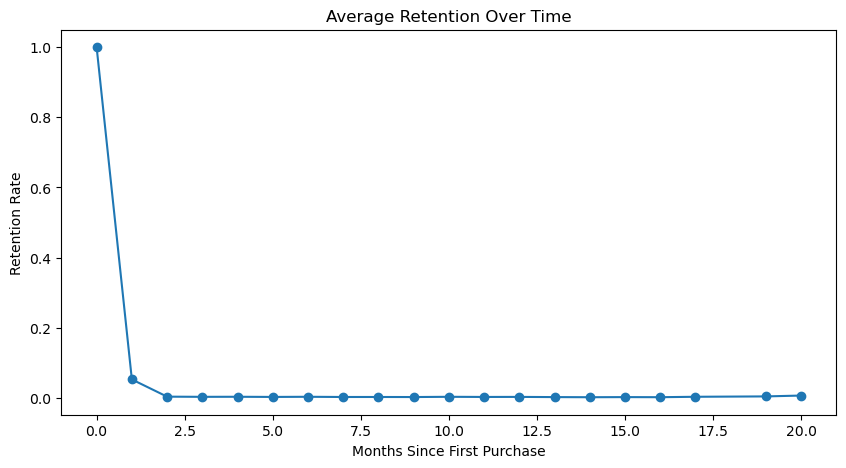

In [25]:
avg_retention = retention.mean(axis=0)

avg_retention.plot(marker='o', figsize=(10,5))
plt.title("Average Retention Over Time")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Retention Rate")
plt.show()

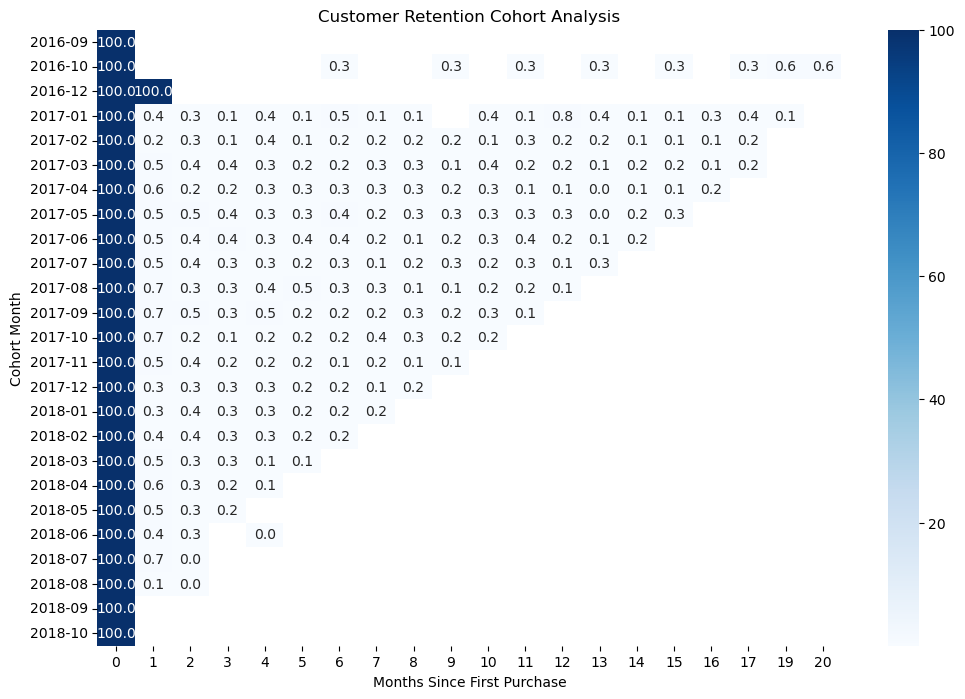

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(retention * 100, annot=True, fmt=".1f", cmap="Blues")

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

In [ ]:
INSIGHTS:

• Customer retention drops sharply after the first purchase, with most cohorts showing less than 1% retention from month 1 onward

• The majority of customers are one-time buyers, indicating weak long-term engagement and low customer lifetime value

• Retention remains consistently low across all cohorts, suggesting a systemic retention issue rather than a time-specific decline

• Minor variations across cohorts indicate small improvements in certain periods, but no sustained retention growth trend

• The business is highly dependent on continuous new customer acquisition rather than repeat purchases

In [ ]:
RECOMMENDATIONS:

• Implement retention strategies such as personalized offers, targeted discounts, and loyalty programs to drive repeat purchases

• Strengthen post-purchase engagement through email campaigns, push notifications, and re-targeting strategies

• Improve overall customer experience (delivery speed, product quality, customer support) to increase satisfaction and retention

• Introduce subscription models or repeat purchase incentives for high-frequency product categories

• Identify and analyze higher-retention cohorts (if any) to replicate successful behavioral patterns across broader customer segments